<a href="https://colab.research.google.com/github/joseydyrueda-code/programacion1/blob/main/taller_de_parcial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#taller para segundo parcial

#

In [2]:
a = np.array(["a", "a", "c", "g", "e", "d", "d", "e", "f"])

In [3]:
np.sort(a) #organiza as letras en orden 'alfabetico'

array(['a', 'a', 'c', 'd', 'd', 'e', 'e', 'f', 'g'], dtype='<U1')

In [4]:
np.unique(a) #elimina valores repetidos y deja un solo valor por cada elemento

array(['a', 'c', 'd', 'e', 'f', 'g'], dtype='<U1')

In [5]:
np.concatenate([a, a]) #duplica o añade otro arreglo justo donde termina el primero

array(['a', 'a', 'c', 'g', 'e', 'd', 'd', 'e', 'f', 'a', 'a', 'c', 'g',
       'e', 'd', 'd', 'e', 'f'], dtype='<U1')

In [8]:
b = np.reshape(a, (3, 3)) #cambia la direccion numpy inicialmente utilizado, en este caso el arreglo es de 3 filas y 3 columnas

In [9]:
import pandas as pd
b_pd =pd.DataFrame(b)
b_pd

,0,1,2
0,a,a,c
1,g,e,d
2,d,e,f


In [10]:
a[a != "b"]

array(['a', 'a', 'c', 'g', 'e', 'd', 'd', 'e', 'f'], dtype='<U1')

In [12]:
a[a == "b"] #se escogen unicamente los valores iguales a b

array([], dtype='<U1')

In [11]:
a[a > "b"]

array(['c', 'g', 'e', 'd', 'd', 'e', 'f'], dtype='<U1')

In [16]:
A = np.array([[1, 2], [2, 4]])
B = np.array([[1, 0], [0, 1]])
A * B #producto de Adamart

array([[1, 0],
       [0, 4]])

In [18]:
np.array([[A, B]])

array([[[[1, 2],
         [2, 4]],

        [[1, 0],
         [0, 1]]]])

In [19]:
import pandas as pd
df = pd.DataFrame({
    "nombre": ["Juan", "Ana", "Jose", "Arturo"],
    "edad": [25, 18, 23, 27],
    "nota": [4.5, 3.2, 4.0, 3.8]
})
df

,nombre,edad,nota
0,Juan,25,4.5
1,Ana,18,3.2
2,Jose,23,4.0
3,Arturo,27,3.8


In [20]:
df["edad"] #eleccionamos una columna

,edad
0,25
1,18
2,23
3,27


In [24]:
df.loc[1]

,1
nombre,Ana
edad,18
nota,3.2


In [26]:
df.loc[df["nombre"] == "Ana"]

,nombre,edad,nota
1,Ana,18,3.2


In [27]:
df.loc[df["edad"] > 23]

,nombre,edad,nota
0,Juan,25,4.5
3,Arturo,27,3.8


In [28]:
df["edad"] = df["edad"].astype(float)

In [30]:
df["edad"].mean() #el promediode la edad es de 23 (saca el promdio de lass edades)

np.float64(23.25)

In [32]:
df.sum() #el metodo concatena cadenas, la edad total de las 3 personas es de 93 años y la nota es de 15

,0
nombre,JuanAnaJoseArturo
edad,93.0
nota,15.5


In [34]:
df.min() #organiza las palabras por orden alfabetico, y para numeros son los valores minimos

,0
nombre,Ana
edad,18.0
nota,3.2


In [37]:
df.max() #hace lo mismo que el de arriba pero con lo maximos


,0
nombre,Juan
edad,27.0
nota,4.5


In [38]:
df.describe() #determina algunas medidas descriptivas dobre las variables cuantitativas de la base de datos

,edad,nota
count,4.00000,4.000000
mean,23.25000,3.875000
std,3.86221,0.537742
min,18.00000,3.200000
25%,21.75000,3.650000
50%,24.00000,3.900000
75%,25.50000,4.125000
max,27.00000,4.500000


In [41]:
df[df["edad"] > 25]

,nombre,edad,nota
3,Arturo,27.0,3.8


funciones lambda

In [43]:
df["edad"].apply(lambda x: x + 1) #le suma 1 a cada 1

,edad
0,26.0
1,19.0
2,24.0
3,28.0


In [45]:
#fijo va a saliren el parcial
import numpy as np
import pandas as pd

np.random.seed(123) #para guardar la semilla

datos = np.random.normal(loc=4.0, scale=0.5, size=50)
#simula 50 valores de la normal con media 4.0 y desviacion estandar de 0.5
df = pd.DataFrame({
           "nota": datos
})

In [46]:
df.describe()

,nota
count,50.000000
mean,4.006636
std,0.600850
min,2.600705
25%,3.610503
50%,3.941306
75%,4.461187
max,5.196183


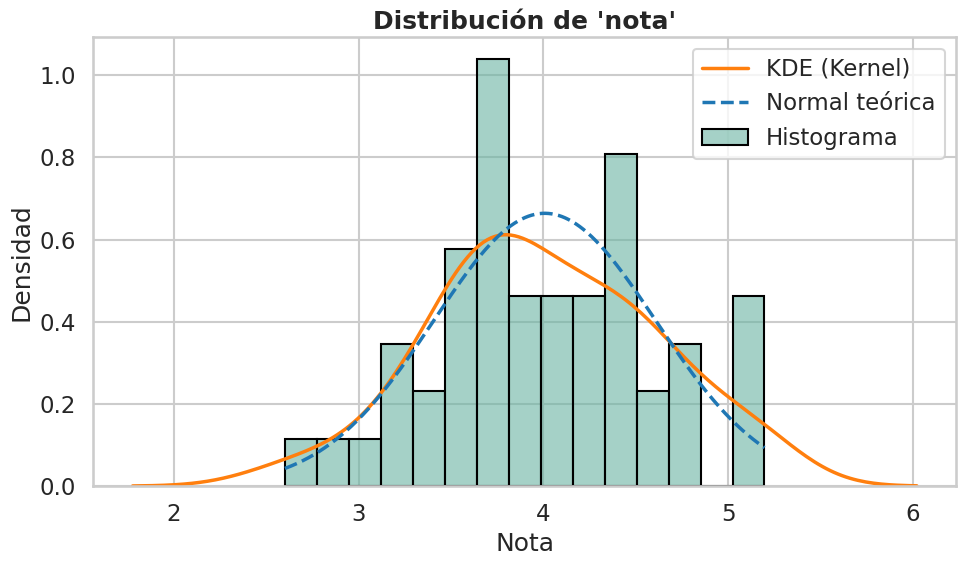

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Estilo bonito
sns.set(style="whitegrid", context="talk")

# Datos
data = df["nota"].dropna()

# Parámetros de la normal
mu, std = data.mean(), data.std()

# Rango para la curva
x = np.linspace(data.min(), data.max(), 1000)

# Crear figura
plt.figure(figsize=(10,6))

# Histograma (normalizado)
sns.histplot(data, bins=15, stat="density", color="#69b3a2", edgecolor="black", alpha=0.6, label="Histograma")

# KDE (estimación por kernel)
sns.kdeplot(data, color="#ff7f0e", linewidth=2.5, label="KDE (Kernel)")

# FDP normal teórica
plt.plot(x, norm.pdf(x, mu, std), color="#1f77b4", linewidth=2.5, linestyle="--", label="Normal teórica")

# Detalles estéticos
plt.title("Distribución de 'nota'", fontsize=18, weight="bold")
plt.xlabel("Nota")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()

# Mostrar
plt.show()

In [49]:
from scipy.stats import shapiro
shapiro(df["nota"])

ShapiroResult(statistic=np.float64(0.9850592402574303), pvalue=np.float64(0.7741499006415689))

si el valor p es mayor que 0.05 no se rechaza la hipotesis nula

In [52]:
import numpy as np
import pandas as pd

np.random.seed(123)

grupo_A = np.random.normal(loc=4.0, scale=0.4, size=40)
grupo_B = np.random.normal(loc=4.3, scale=0.5, size=40)

df = pd.DataFrame({
    "A": grupo_A,
    "B": grupo_B
})


In [53]:
from scipy import stats
t_stat, p_val = stats.ttest_ind(df["A"], df["B"])

print("estadistico t:", t_stat)
print("valor p:", p_val)

estadistico t: -3.350606843435094
valor p: 0.0012449635545749276


se rechaza que las calificaciones de los grupos sean igualescon una seguridad del 95 %